# Analiza igralcev lige NFL v rednem delu sezone 2025/26

Analizirali bomo podatke o NFL igralcih iz sezone 2025/26, pridobljene s portala [Pro-Football-Reference](https://www.pro-football-reference.com). Zajeti so podatki o podajah (Passing), tekih (Rushing) in ujetih podajah (Receiving).

#### Priprava podatkov

Najprej uvozimo vse potrebne knjižnice ter pripravimo podatke za analizo in opravimo pretvorbe za kasnejšo uporabo. Številske stolpce pretvorimo v ustrezne tipe in ustvarimo dodatne metrike za analizo učinkovitosti igralcev.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

df = pd.read_csv("podatki/nfl_2025_statistika.csv")

df["skupni_jardi"] = (
    df.get("passing_yards", 0)
    + df.get("rushing_yards", 0)
    + df.get("receiving_yards", 0)
)

df["skupni_td"] = (
    df.get("passing_td", 0)
    + df.get("rushing_td", 0)
    + df.get("receiving_td", 0)
)

for c in df.select_dtypes(include=["number"]).columns:
    df[c] = df[c].fillna(0).astype(int)

df["yards_per_att"] = df["passing_yards"] / df["passing_att"].replace(0, pd.NA)
df["td_rate"] = df["passing_td"] / df["passing_att"].replace(0, pd.NA) * 100
df["jardi_na_tek"] = df["rushing_yards"] / df["rushing_att"].replace(0, pd.NA)
df["poskusov_na_td"] = df["rushing_att"] / df["rushing_td"].replace(0, pd.NA)
df["vrednost_receiverja"] = (
    df["receiving_yards"] + df["receiving_td"] * 20 + df["receptions"] * 2
) / df["tekme"].replace(0, pd.NA)
df["catch_rate"] = (
    df["receptions"] / df["targets"].replace(0, pd.NA) * 100
)

display(df)

,igralec,ekipa,passing_yards,passing_td,passing_att,passing_cmp,passing_int,sacks,rushing_yards,rushing_td,...,starost,tekme,skupni_jardi,skupni_td,yards_per_att,td_rate,jardi_na_tek,poskusov_na_td,vrednost_receiverja,catch_rate
0,A'Shawn Robinson,CAR,0,0,0,0,0,0,0,0,...,30,17,0,0,<NA>,<NA>,<NA>,<NA>,0.0,<NA>
1,A.J. Brown,PHI,0,0,0,0,0,0,0,0,...,28,15,1003,7,<NA>,<NA>,<NA>,<NA>,86.6,64.46281
2,A.J. Epenesa,BUF,0,0,0,0,0,0,0,0,...,27,16,0,0,<NA>,<NA>,<NA>,<NA>,0.0,<NA>
3,A.J. Green,MIA,0,0,0,0,0,0,0,0,...,27,3,0,0,<NA>,<NA>,<NA>,<NA>,0.0,<NA>
4,AJ Barner,SEA,0,0,0,0,0,0,14,1,...,23,17,533,7,<NA>,<NA>,1.4,10.0,43.705882,76.470588
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1760,Zeek Biggers,MIA,0,0,0,0,0,0,0,0,...,22,9,0,0,<NA>,<NA>,<NA>,<NA>,0.0,<NA>
1761,Zion Childress,DAL,0,0,0,0,0,0,0,0,...,23,3,0,0,<NA>,<NA>,<NA>,<NA>,0.0,<NA>
1762,Zion Logue,BUF,0,0,0,0,0,0,0,0,...,24,3,0,0,<NA>,<NA>,<NA>,<NA>,0.0,<NA>
1763,Zonovan Knight,ARI,0,0,0,0,0,0,269,4,...,24,12,429,5,<NA>,<NA>,3.280488,20.5,18.666667,70.967742


## Pregled najboljših igralcev

Spodaj je prikazana tabela 10 najučinkovitejših igralcev lige glede na skupno število pridobljenih jardov (podaje + teki + sprejemi) v sezoni. Tabela vključuje tudi podrobnejše podatke pridobljenih jardov po posameznih kategorijah ter skupno število doseženih touchdownov (`total_td`).

In [46]:
top_10 = df.sort_values("skupni_jardi", ascending=False).head(10).reset_index(drop=True)
top_10.index += 1

display(top_10[[ "igralec", "ekipa", "pozicija", "tekme","passing_yards", "rushing_yards", "receiving_yards","skupni_jardi", "skupni_td"]])

,igralec,ekipa,pozicija,tekme,passing_yards,rushing_yards,receiving_yards,skupni_jardi,skupni_td
1,Drake Maye,NWE,QB,17,4394,450,2,4846,35
2,Dak Prescott,DAL,QB,17,4552,177,0,4729,32
3,Matthew Stafford,LAR,QB,17,4707,1,0,4708,46
4,Jared Goff,DET,QB,17,4564,45,0,4609,34
5,Trevor Lawrence,JAX,QB,17,4007,359,0,4366,38
6,Caleb Williams,CHI,QB,17,3942,388,22,4352,31
7,Bo Nix,DEN,QB,17,3931,356,0,4287,30
8,Josh Allen,BUF,QB,17,3668,579,0,4247,39
9,Justin Herbert,LAC,QB,16,3727,498,0,4225,28
10,Sam Darnold,SEA,QB,17,4048,95,0,4143,25


Pričakovano so vsi igralci podajalci, saj imajo najlažji dostop do pridobitve jardov.

## 1. Analiza podajalcev (quarterback)

#### Najboljša razmerja med touchdowni (TD) in prestreženimi podajami (INT)

Spodnji graf prikazuje podajalce, ki so dosegli vsaj 10 touchdownov in zbrali vsaj 1500 jardov s podajo, razvrščeni glede na učinkovitost (razmerje med TD in INT)

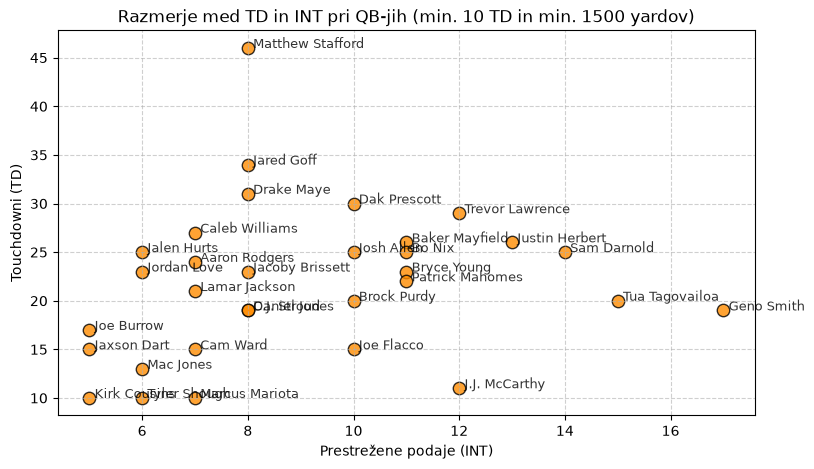

In [47]:
qb_graf_df = df[(df["pozicija"] == "QB") & (df["passing_td"] >= 10) & (df["passing_yards"] >= 1500)].copy()

plt.figure(figsize=(9, 5))
plt.scatter(qb_graf_df["passing_int"], qb_graf_df["passing_td"], color="darkorange", s=80, edgecolors="black", alpha=0.8)

plt.title("Razmerje med TD in INT pri QB-jih (min. 10 TD in min. 1500 yardov)")
plt.xlabel("Prestrežene podaje (INT)")
plt.ylabel("Touchdowni (TD)")
plt.grid(True, linestyle="--", alpha=0.6)

for i, row in qb_graf_df.iterrows():
    plt.annotate(row["igralec"], (row["passing_int"] + 0.1, row["passing_td"]), fontsize=9, alpha=0.8)

plt.show()

Na grafu izstopa Matthew Stafford, ki je bil razglašen za najboljšega igralca sezone (MVP). Pod njim sta dva neposredna konkurenta za to nagrado, Jared Goff in Drake Maye. 

#### Agresivnost 
Obstajajo različni tipi podajalcev. Taki, ki igrajo bolj konzervativno in taki, ki agresivno napadajo nove jarde. Poglejmo podajalce z največ jardov na met. Omejimo z vsaj 200 poskusov podaj.

In [48]:
qbji = df[(df["pozicija"] == "QB") & (df["passing_att"] >= 200)].copy()
top_yA = qbji.sort_values("yards_per_att", ascending=False).head(10).reset_index(drop=True)
top_yA.index += 1

display(top_yA[[ "igralec", "ekipa", "passing_att","passing_yards", "passing_td", "yards_per_att"]])


,igralec,ekipa,passing_att,passing_yards,passing_td,yards_per_att
1,Drake Maye,NWE,492,4394,31,8.930894
2,Sam Darnold,SEA,477,4048,25,8.486373
3,Lamar Jackson,BAL,302,2549,21,8.440397
4,Daniel Jones,IND,384,3101,19,8.075521
5,Josh Allen,BUF,460,3668,25,7.973913
6,Jared Goff,DET,578,4564,34,7.896194
7,Matthew Stafford,LAR,597,4707,46,7.884422
8,Jordan Love,GNB,439,3381,23,7.701595
9,Brock Purdy,SFO,284,2167,20,7.630282
10,Dak Prescott,DAL,600,4552,30,7.586667


Primerjajmo zdaj te rezultate z odstotkom touchdownov.

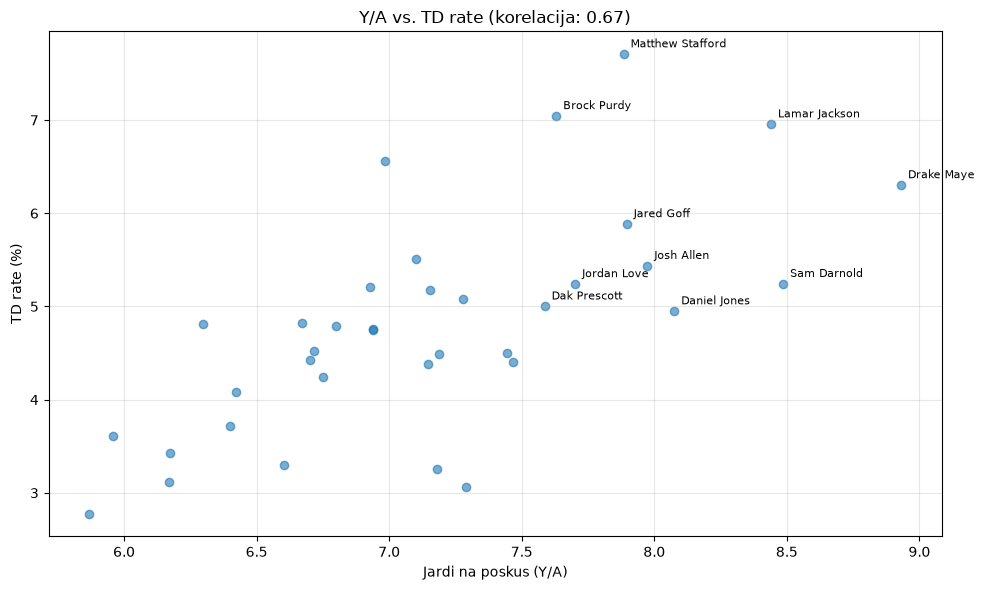

In [49]:
korelacija = qbji["yards_per_att"].corr(qbji["td_rate"])

plt.figure(figsize=(10, 6))
plt.scatter(qbji["yards_per_att"], qbji["td_rate"], alpha=0.6)

for _, vrstica in top_yA.iterrows():
    plt.annotate(
        vrstica["igralec"],
        (vrstica["yards_per_att"], vrstica["td_rate"]),
        textcoords="offset points", xytext=(5, 5), fontsize=8
    )

plt.xlabel("Jardi na poskus (Y/A)")
plt.ylabel("TD rate (%)")
plt.title(f"Y/A vs. TD rate (korelacija: {korelacija:.2f})")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Vidimo, da so najbolši podajalci z razlogom agresivni, saj jih je večina tudi med najbolj efektivnimi (dober TD rate).

## 2. Analiza tekačev (running back)

#### Igralci, ki so pridobili največ jardov s tekom
V tabeli vidimo igralce, ki so svoji ekipi prinesli največ jardov s tekom z žogo.

In [29]:
top_10_rb_skupaj = df[df["pozicija"] == "RB"].sort_values(by="rushing_yards", ascending=False).head(10).copy()

top_10_rb_skupaj = top_10_rb_skupaj.reset_index(drop=True)
top_10_rb_skupaj.index = top_10_rb_skupaj.index + 1


top_10_rb_skupaj[["igralec", "ekipa", "rushing_att", "rushing_yards", "rushing_td"]]

,igralec,ekipa,rushing_att,rushing_yards,rushing_td
1,James Cook,BUF,309,1621,12
2,Derrick Henry,BAL,307,1595,16
3,Jonathan Taylor,IND,323,1585,18
4,Bijan Robinson,ATL,287,1478,7
5,De'Von Achane,MIA,238,1350,8
6,Kyren Williams,LAR,259,1252,10
7,Jahmyr Gibbs,DET,243,1223,13
8,Christian McCaffrey,SFO,311,1202,10
9,Javonte Williams,DAL,252,1201,11
10,Saquon Barkley,PHI,280,1140,7


Primarna naloga tekačev je pridobitev jardov s tekom (rushing yards). Največ jih je svoji ekipi prinesel James Cook, ne daleč za njim pa sta Derrick Henry in Jonathan Taylor, vsi trije spadajo med najboljše tekače v ligi.

#### Učinkovitost ali le velika obremenitev?
Poglejmo primerjavo med tem, koliko jardov so igralci pridobili na vsak tek in njihovimi skupnimi jardi, torej učinkovitost igralca ob vsakem poskusu.


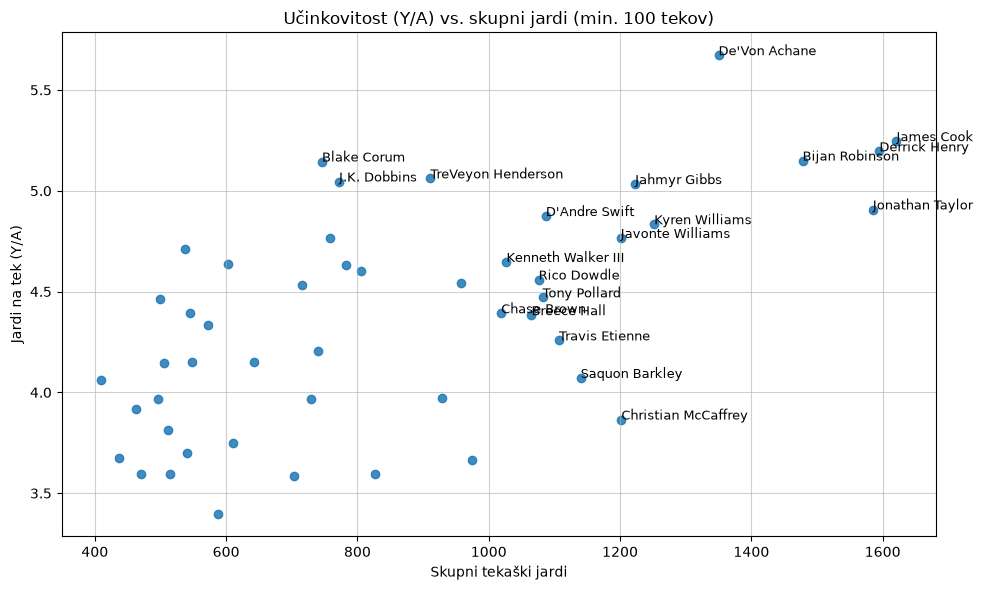

In [50]:
rb_analiza = df[(df["pozicija"] == "RB") & (df["rushing_att"] >= 100)].copy()

plt.figure(figsize=(10, 6))
plt.scatter(rb_analiza["rushing_yards"], rb_analiza["jardi_na_tek"], alpha=0.85)

for _, vrstica in rb_analiza.iterrows():
    if vrstica["rushing_yards"] > 1000 or vrstica["jardi_na_tek"] > 5:
        plt.annotate(
            vrstica["igralec"],
            (vrstica["rushing_yards"], vrstica["jardi_na_tek"]),
            fontsize=9
        )

plt.title("Učinkovitost (Y/A) vs. skupni jardi (min. 100 tekov)")
plt.xlabel("Skupni tekaški jardi")
plt.ylabel("Jardi na tek (Y/A)")
plt.grid(True, alpha=0.6)
plt.tight_layout()
plt.show()

Pričakovano so najboljši tekači v ligi zelo učinkoviti in zelo obremenjeni. Največ jardov na tek je pridobil De'Von Achane, malo več kot 5,5.

#### Učinkovitost tekačev v rdeči coni (zadnjih 10 jardih)
V rdeči coni se ekipe največkrat odločijo za tek. Poglejmo, koliko tekaških poskusov v povprečju mora tekač opraviti, da doseže touchdown. Omejimo s tem, da je moral imeti igralec vsaj 5 doseženih touchdownov.

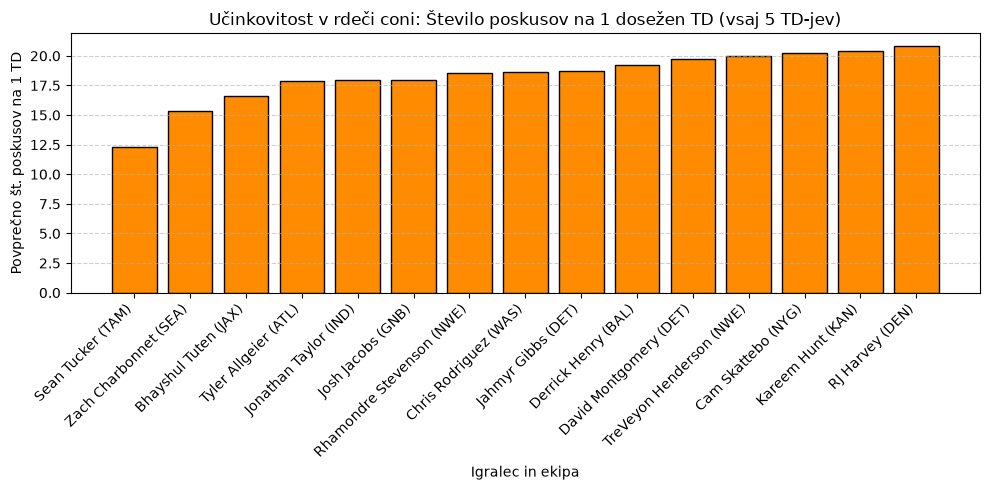

In [51]:
rb_td = df[(df["pozicija"] == "RB") & (df["rushing_td"] >= 5)].copy()
rb_td["poskusov_na_td"] = rb_td["rushing_att"] / rb_td["rushing_td"]

top_td_stroj = rb_td.sort_values(by="poskusov_na_td", ascending=True).head(15)

plt.figure(figsize=(10, 5))
plt.bar(top_td_stroj["igralec"] + " (" + top_td_stroj["ekipa"] + ")", top_td_stroj["poskusov_na_td"], color="darkorange", edgecolor="black")
plt.title("Učinkovitost v rdeči coni: Število poskusov na 1 dosežen TD (vsaj 5 TD-jev)")
plt.xlabel("Igralec in ekipa")
plt.ylabel("Povprečno št. poskusov na 1 TD")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

Opazimo nekaj novih imen, ki jih ni bilo med najboljšimi tekači. To je zato, ker imajo ekipe specifične igralce, ki jih uporabijo samo v določenih situacijah. Sean Tucker največkrat dobi priložnost le takrat, ko mora ekipa pridobiti manj kot 5 jardov za touchdown ali nov prvi poskus. Na splošno pa se število tekov, potrebnih za touchdown, med najboljšimi tekači giblje med 15 in 20.

## 3. Analiza sprejemalcev (receiver)

Cilj sprejemalcev je, da svoji ekipi prinesejo čim več jardov in čim več touchdownov. Seštejmo jarde, touchdowne s faktorjem 20 (fantasy football pretvorba) in sprejeme s faktorjem 2. Vsoto delimo s številom odigranih tekem in za konec še omejimo število sprejemov na vsaj 50, da dobimo "vrednost sprejemalca".

In [52]:
receiverji = df[df["receptions"] >= 50]
top_receiverji = receiverji.sort_values(
    "vrednost_receiverja", ascending=False
).head(10).reset_index(drop=True)
top_receiverji.index += 1

display(top_receiverji[["igralec", "ekipa", "tekme","receiving_yards", "receiving_td","receptions", "vrednost_receiverja"]])

,igralec,ekipa,tekme,receiving_yards,receiving_td,receptions,vrednost_receiverja
1,Puka Nacua,LAR,16,1715,10,129,135.8125
2,Jaxon Smith-Njigba,SEA,17,1793,10,119,131.235294
3,Ja'Marr Chase,CIN,16,1412,8,125,113.875
4,Amon-Ra St. Brown,DET,17,1401,11,117,109.117647
5,George Pickens,DAL,17,1429,9,93,105.588235
6,Trey McBride,ARI,17,1239,11,126,100.647059
7,Drake London,ATL,12,919,7,68,99.583333
8,Rashee Rice,KAN,8,571,5,53,97.125
9,Chris Olave,NOR,16,1163,9,100,96.4375
10,Nico Collins,HOU,15,1117,6,71,91.933333


Na vrhu so trije sprejemalci, ki bi jih mnogi analitiki uvrstili med najboljše 3, kar daje enačbi smiselnost.

#### Učinkovitost

Primerjajmo število podaj proti igralcu, s številom ujetih podaj tega igralca in s tem analizirajmo učinkovitost sprejemalca.

In [61]:
df_receiving = df[df["targets"] >= 50]

top_reliable = df_receiving.sort_values(
    "catch_rate", ascending=False
).head(10).reset_index(drop=True)

top_reliable.index += 1

display(top_reliable[[ "igralec", "ekipa", "targets", "receptions", "catch_rate"]])

,igralec,ekipa,targets,receptions,catch_rate
1,Tyjae Spears,TEN,50,45,90.0
2,Kenneth Gainwell,PIT,85,73,85.882353
3,Jonathan Taylor,IND,55,46,83.636364
4,Stefon Diggs,NWE,102,85,83.333333
5,George Kittle,SFO,69,57,82.608696
6,Jahmyr Gibbs,DET,94,77,81.914894
7,RJ Harvey,DEN,58,47,81.034483
8,Jake Ferguson,DAL,102,82,80.392157
9,Gunnar Helm,TEN,55,44,80.0
10,Christian McCaffrey,SFO,129,102,79.069767


Zdaj pa poglejmo še učinkovitost treh najboljših sprejemalcev sodeč po naši metriki "vrednosti sprejemalca".

In [65]:
iskani_igralci = "puka nacua|jaxon smith-njigba|ja'marr chase"

df_filtered = df[
    df["igralec"].str.lower().str.contains(iskani_igralci, na=False)
]

display(df_filtered[["igralec", "ekipa", "targets", "receptions", "catch_rate"]].style.hide(axis="index"))

igralec,ekipa,targets,receptions,catch_rate
Ja'Marr Chase,CIN,185,125,67.567568
Jaxon Smith-Njigba,SEA,163,119,73.006135
Puka Nacua,LAR,166,129,77.710843


Vsi trije imajo odstotek ujetih žog pod 80, Chase celo pod 70. To nakazuje na to, da metrika bolj nagrajuje skupno delovno obremenitev. Igralec je lahko torej izjemno produktiven kljub nižjemu deležu ulovljenih žog, če prejme dovoljšno količino podaj v njegovo smer. Naredimo primerjavo učinkovitosti in "vrednosti sprejemalca". 

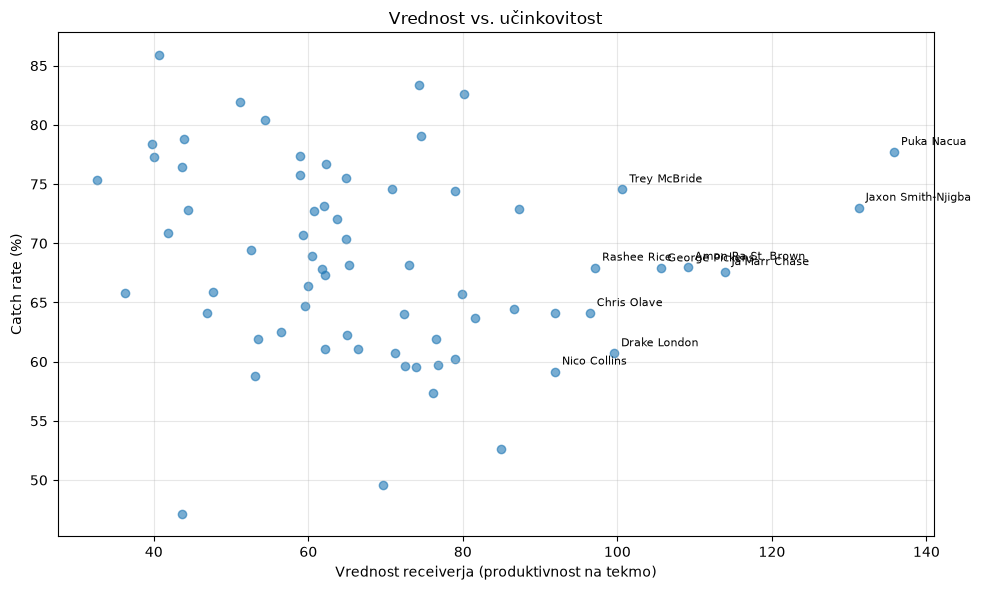

In [66]:
plt.figure(figsize=(10, 6))
plt.scatter(
    receiverji["vrednost_receiverja"],
    receiverji["catch_rate"],
    alpha=0.6
)

for _, vrstica in top_receiverji.iterrows():
    plt.annotate(
        vrstica["igralec"],
        (vrstica["vrednost_receiverja"], vrstica["catch_rate"]),
        textcoords="offset points", xytext=(5, 5), fontsize=8
    )

plt.xlabel("Vrednost receiverja (produktivnost na tekmo)")
plt.ylabel("Catch rate (%)")
plt.title("Vrednost vs. učinkovitost")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Spet vidimo, da najboljši sprejemalci niso nujno hkrati najbolj učinkoviti.

#### Razvrstitev podaj proti igralcem, glede na njihovo pozicijo, pri najbolši ekipi sezone Los Angeles Rams (Target Share)

Najprej poglejmo, kolikokrat je bil ciljan posamezni igralec.

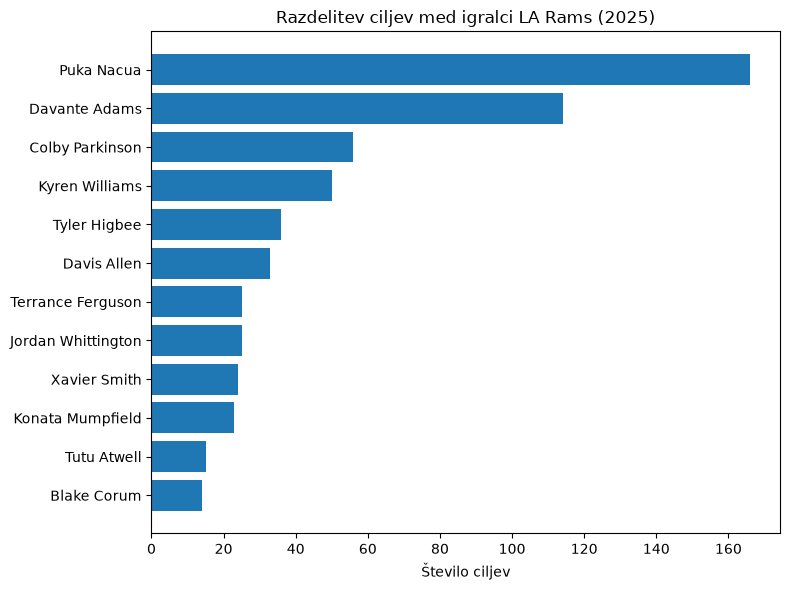

In [67]:
rams = df[(df["ekipa"] == "LAR") & (df["targets"] > 0)]
rams_graf = rams.sort_values("targets")

plt.figure(figsize=(8, 6))
plt.barh(rams_graf["igralec"], rams_graf["targets"])
plt.xlabel("Število ciljev")
plt.title("Razdelitev ciljev med igralci LA Rams (2025)")
plt.tight_layout()
plt.show()

Podoben razpored bi videli v vseh ekipah, torej, da je en igralec prvo orožje v napadu (WR1).

Ker pa so sprejemalci v svoji kategoriji razdeljeni, si poglejmo cilje podaj glede na specifične sprejemalce.

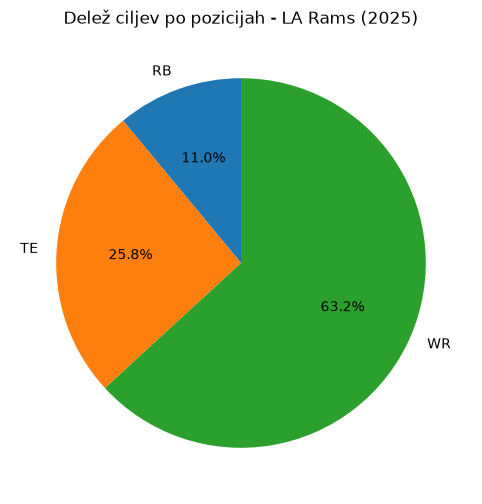

In [68]:
cilji_po_poziciji = rams.groupby("pozicija")["targets"].sum()

plt.figure(figsize=(6, 6))
plt.pie(cilji_po_poziciji, labels=cilji_po_poziciji.index, autopct="%1.1f%%", startangle=90)
plt.title("Delež ciljev po pozicijah - LA Rams (2025)")
plt.show()

Največ podaj prejmejo hitri sprejemalci (WR), medtem ko si približno tretjino razdelijo okretnejši sprejemalci (TE) in tekači. Podoben trend bi videli v vseh ekipah.

## Zaključek
Analiza NFL igralcev sezone 2025/26 pokaže, da skupne jarde pričakovano dominirajo podajalci, saj imajo zaradi narave igre največji dostop do njihovega zbiranja – med desetimi najproduktivnejšimi igralci lige ni niti enega tekača ali sprejemalca. Pri tekačih je opazna jasna povezava med obremenitvijo in učinkovitostjo, v rdeči coni pa se izkažejo tudi igralci, ki sicer niso med vodilnimi po skupnih jardih, a jih ekipe namensko uporabljajo v situacijah tik pred touchdownom. Pri sprejemalcih analiza pokaže, da najvišja produktivnost (vrednost sprejemalca) ni nujno povezana z visokim odstotkom ulovljenih žog, saj imajo vsi trije vodilni sprejemalci catch rate pod 80 %, kar nakazuje, da količina prejetih podaj šteje vsaj toliko kot zanesljivost ulova. Na primeru Los Angeles Rams se potrdi tudi splošen vzorec razporeditve podaj v ligi: večino ciljev prejmejo hitri sprejemalci (WR), preostanek pa si razdelijo okretnejši sprejemalci (TE) in tekači.
 